# Fine-tuning GPT-3 using the OpenAI API and Python

reference: https://www.datacamp.com/tutorial/fine-tuning-gpt-4o-mini

Before you start fine-tuning the GPT-4o Mini model, we recommend prompt engineering, prompt chaining, and function calling to customize the model responses and get domain-specific answers.

Fine-tuning is necessary when you want to adjust the style, tone, or format. It is used to improve reliability and accuracy, handle complex prompts, or perform a new task that the prompt engineer could not achieve.

In this tutorial, we will fine-tune the GPT-4o Mini model to classify text into "stress" and "non-stress" labels. Subsequently, we will access the fine-tuned model using the OpenAI API and the OpenAI playground. Finally, we will evaluate the fine-tuned model by comparing its performance before and after tuning it using various classification metrics.

In [84]:
import sys
import os
from IPython.display import display, Markdown
from openai import OpenAI
import numpy as np

# Use current working directory and go one level up
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

# Now you can import your config
from config import api_key

client = OpenAI(api_key=api_key)

## Introducing GPT-4o Mini
GPT-4o Mini is the most cost-efficient general large language model available. It scores 82% on the MMLU and currently outperforms Claude 3.5 Sonnet on chat preferences in the LMSYS leaderboard. It is priced at 15 cents per million input tokens and 60 cents per million output tokens, which is 60% cheaper than GPT-3.5 Turbo.

GPT-4o mini currently supports text and images as input. The model has a context window of 128K tokens, supports up to 16K output tokens per request, and has knowledge up to October 2023. GPT-4o Mini can handle non-English text, as it is using the GPT-4o tokenizer. We get the best of both worlds at a low cost.

Learn about the use case, chat completion API, and detailed benchmarks of GPT-4o Mini by reading our blog, What Is GPT-4o Mini?

In [2]:
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
    {"role": "system", "content": "You are a great philosopher."},
    {"role": "user", "content": "What is the meaning of life?"}
  ])

In [12]:
# Nice feature 
display(Markdown(response.choices[0].message.content))

The question of life's meaning has been pondered by philosophers, theologians, and thinkers for centuries, and there is no single answer that satisfies everyone. Different philosophical traditions offer varying perspectives:

1. **Existentialism**: Figures like Jean-Paul Sartre and Albert Camus argue that life inherently lacks meaning, but individuals have the freedom to create their own purpose through choices and actions.

2. **Religious Views**: Many religious traditions propose that the meaning of life is connected to a higher power or purpose. For example, Christianity might suggest that life's meaning is found in a relationship with God, while Buddhism may emphasize enlightenment and the alleviation of suffering.

3. **Utilitarianism**: This philosophy posits that the meaning of life can be found in actions that maximize happiness and minimize suffering for the greatest number of people.

4. **Humanism**: A humanistic approach might emphasize the importance of human experiences, relationships, and contributions to society as sources of meaning.

5. **Absurdism**: As articulated by Camus, absurdism acknowledges the conflict between humans' search for meaning and the indifferent universe. Embracing this absurdity can lead to personal freedom and authenticity.

Ultimately, the meaning of life may be best defined by each individual based on their values, experiences, and beliefs. It's a deeply personal journey that can evolve over time, shaped by our interactions with the world and those around us. What remains crucial is the quest itself—seeking, reflecting, and finding significance in the experiences we have.

## Creating the dataset
We will now load and process the dataset.

- Load the top 200 rows from the Reddit post dataset.
- Drop all columns except 'title' and 'label'.
- Map the labels column to convert 0 and 1 into "non-stress" and "stress" labels.
- Split the dataset into training and validation sets.
- Save both the training and validation sets in JSONL format.

In [24]:
import pandas as pd
import json
from sklearn.model_selection import train_test_split

pd.set_option('display.max_colwidth', None)

# Load the CSV file with the correct delimiter
file_path = "Reddit_Title.csv" 
data = pd.read_csv(file_path, sep=";")

# clean up and drop unnecessary columns and select the top 200 rows
data_cleaned = data[["title","label"]].head(200)

# Mapping the `label` column to more human-readable text
label_mapping = {0: "non-stress", 1: "stress"}
data_cleaned['label'] = data_cleaned['label'].map(label_mapping)

# Split the data into training and validation sets (80% train, 20% validation)
train_data, validation_data = train_test_split(data_cleaned, test_size=0.2, random_state=42)



In [39]:
def save_to_jsonl(data, output_file_path):
    jsonl_data = []
    for index, row in data.iterrows():
        jsonl_data.append({
            "messages": [
                {"role": "system", "content": "Given a social media post, classify whether it indicates 'stress' or 'non-stress'."},
                {"role": "user", "content": row['title']},
                {"role": "assistant", "content": f"\"{row['label']}\""}
            ]
        })

    # Save to JSONL format
    with open(output_file_path,"w") as f:
        for item in jsonl_data:
            f.write(json.dumps(item) + '\n')

# Save the training and validation sets to separate JSONL files
train_output_file_path = 'stress_detection_train.jsonl' 
validation_output_file_path = 'stress_detection_validation.jsonl'

save_to_jsonl(train_data, train_output_file_path)
save_to_jsonl(validation_data, validation_output_file_path)

print(f"Training dataset save to {train_output_file_path}")
print(f"Validation dataset save to {validation_output_file_path}")

Training dataset save to stress_detection_train.jsonl
Validation dataset save to stress_detection_validation.jsonl


### Uploading the dataset

We will now use the OpenAI client to upload both the training and validation datasets for fine-tuning.

In [40]:
train_file = client.files.create(
  file=open(train_output_file_path, "rb"),
  purpose="fine-tune"
)

In [41]:
valid_file = client.files.create(
  file=open(validation_output_file_path, "rb"),
  purpose="fine-tune"
)

print(f"Training file Info: {train_file}")
print(f"Validation file Info: {valid_file}")

Training file Info: FileObject(id='file-DsBBsayLkEhtCNMLNs4dQx', bytes=50323, created_at=1751997930, filename='stress_detection_train.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)
Validation file Info: FileObject(id='file-PRi84YRqV8MubH5iG7EeP4', bytes=12724, created_at=1751997946, filename='stress_detection_validation.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)


To check if the dataset has been successfully pushed to the cloud, go to the Dashboard and click on the “Storage” tab. Two files will be there and ready to be used. (July 2025 this was located at Dashboard and then storage)

## Starting the fine-tuning job

Create the fine-tuning job using the client API. The fine-tuning function requires the training dataset file ID, validation dataset file ID, model name, and hyperparameters. We will fine-tune our model for three epochs. To improve the model performance, you can always train on the full dataset with at least 5 epochs.

In [42]:
model = client.fine_tuning.jobs.create(
  training_file=train_file.id, 
  validation_file=valid_file.id,
  model="gpt-4o-mini-2024-07-18", 
  hyperparameters={
    "n_epochs": 3,
	"batch_size": 3,
	"learning_rate_multiplier": 0.3
  }
)
job_id = model.id
status = model.status

print(f'Fine-tuning model with jobID: {job_id}.')
print(f"Training Response: {model}")
print(f"Training Status: {status}")

Fine-tuning model with jobID: ftjob-MQSmiWtn4ZdsFoDJsQhqcYxS.
Training Response: FineTuningJob(id='ftjob-MQSmiWtn4ZdsFoDJsQhqcYxS', created_at=1751998547, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size=3, learning_rate_multiplier=0.3, n_epochs=3), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-06TbjnMmqCxUuiUIunjkEDty', result_files=[], seed=745768760, status='validating_files', trained_tokens=None, training_file='file-DsBBsayLkEhtCNMLNs4dQx', validation_file='file-PRi84YRqV8MubH5iG7EeP4', estimated_finish=None, integrations=[], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size=3, learning_rate_multiplier=0.3, n_epochs=3))), user_provided_suffix=None, usage_metrics=None, shared_with_openai=False, eval_id=None)
Training Status: validating_files


Under `Dashboard` we can check the finetuning status or with code: 

In [77]:
# Retrieve the state of a fine-tune
client.fine_tuning.jobs.retrieve(job_id)

FineTuningJob(id='ftjob-MQSmiWtn4ZdsFoDJsQhqcYxS', created_at=1751998547, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=1751999030, hyperparameters=Hyperparameters(batch_size=3, learning_rate_multiplier=0.3, n_epochs=3), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-06TbjnMmqCxUuiUIunjkEDty', result_files=[], seed=745768760, status='running', trained_tokens=None, training_file='file-DsBBsayLkEhtCNMLNs4dQx', validation_file='file-PRi84YRqV8MubH5iG7EeP4', estimated_finish=None, integrations=[], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size=3, learning_rate_multiplier=0.3, n_epochs=3))), user_provided_suffix=None, usage_metrics=None, shared_with_openai=False, eval_id=None)

In [78]:
job = client.fine_tuning.jobs.retrieve(job_id)

In [79]:
job.status

'running'

THIS TOOK A LONG TIME SO continue the code with another model

When the fine-tuning job is completed, you will receive an email telling you that the fine-tuned model is ready to be used.

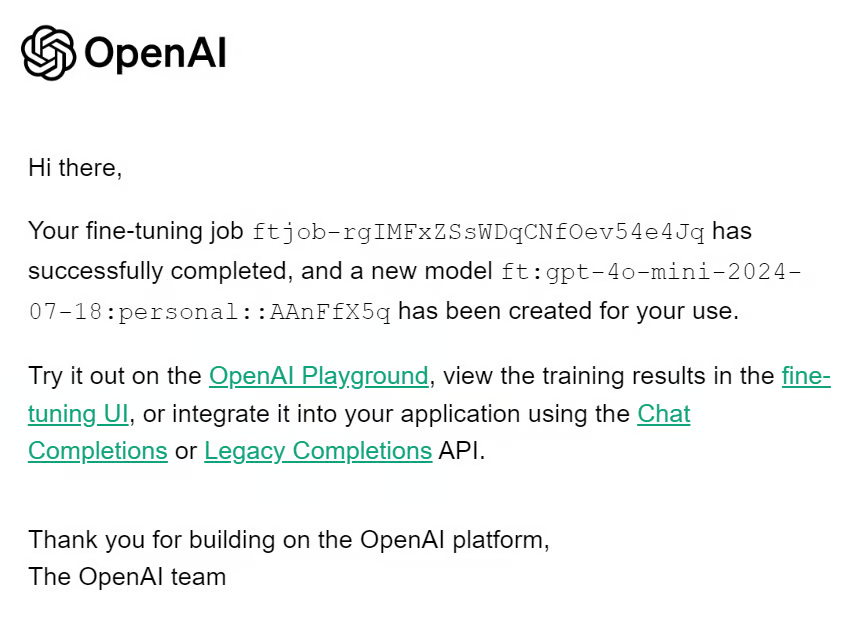

## Accessing the Fine-tuned Model using the API

To access the fine-tuned model, we need to obtain the name of the fine-tuned model. To do this, we will gather information on all fine-tuning jobs, select the latest one, and then select the model name.

In [67]:
result = client.fine_tuning.jobs.list()

# Retrieve the fine tuned model
fine_tuned_model = result.data[0].fine_tuned_model
print(fine_tuned_model)

None


Generate repose by providing the chat completion function with a fine-tuned model name, messages with a correct system prompt, and a sample from the dataset.

**remark** - I use and openAI model my fine-tuning took too long and potentially costs too much money

In [80]:
completion = client.chat.completions.create(
  model = "gpt-4o-mini",
  messages=[
    {"role": "system", "content": "Given a social media post, classify whether it indicates 'stress' or 'non-stress'."},
    {"role": "user", "content": "Just went to my first homecoming, and they played a song I've always wanted to dance to at an official dance. Sorry for the terrible quality, but my happiness in this moment couldn't be exaggerated!"}
  ]
)
print(completion.choices[0].message.content)

Non-stress


Success! I have predicted the label correctly.

If you are unsatisfied with your model, you can always delete it using the following command. We won't be doing it as we must run additional model evaluations first.

In [81]:
# Delete a fine-tuned model (must be an owner of the org the model was created in)
#client.models.delete(fine_tuned_model)

## Accessing the Fine-tuned Model Using Playground
There is another way to access the fine-tuned model and test it on various prompts more efficiently.

Go to the OpenAI dashboard, click on the "Fine-tuning" tab, select the recently run job, and then click the "Playground" button located at the bottom right.

It will take you to the chatbot application. There, you can provide a system prompt and start typing the sample Reddit post. 

## Model Evaluation

We have fine-tuned the model and think that it is good enough. But have you even considered whether it was already better from the start? We haven't done a detailed before-and-after comparison. 

In this section, we will use validation data to predict the labels using the base model and then compare it with a fine-tuned model. We will compare both models based on accuracy, classification report, and confusion metrics. 

### Model evaluation before fine-tuning
Create a `predict` function that inputs the dataset and model name to generate a list of predicted labels. It uses the same system messages and post titles from the dataset.

In [82]:
def predict(test, model):
    y_pred = []
    categories = ["non-stress", "stress"]

    for index, row in test.iterrows():
        response = client.chat.completions.create(
            model=model,
            messages=[
                {
                    "role": "system",
                    "content": "Given a social media post, classify whether it indicates 'stress' or 'non-stress'.",
                },
                {"role": "user", "content": row["title"]},
            ],
        )

        answer = response.choices[0].message.content

        # Determine the predicted category

        for category in categories:
            if category.lower() in answer.lower():
                y_pred.append(category)
                break
        else:
            y_pred.append("none")
    return y_pred

Then, we will create the evaluate function, which will use the predicted and actual labels to generate an accuracy score, classification report, and confusion metrics.

In [86]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

def evaluate(y_true, y_pred):
    labels = ["non-stress", "stress"]
    mapping = {label: idx for idx, label in enumerate(labels)}

    def map_func(x):
        return mapping.get(
            x, -1
        )  # Map to -1 if not found, but should not occur with correct data

    y_true_mapped = np.vectorize(map_func)(y_true)
    y_pred_mapped = np.vectorize(map_func)(y_pred)

    # Calculate accuracy

    accuracy = accuracy_score(y_true=y_true_mapped, y_pred=y_pred_mapped)
    print(f"Accuracy: {accuracy:.3f}")

    # Generate accuracy report

    unique_labels = set(y_true_mapped)  # Get unique labels

    for label in unique_labels:
        label_indices = [
            i for i in range(len(y_true_mapped)) if y_true_mapped[i] == label
        ]
        label_y_true = [y_true_mapped[i] for i in label_indices]
        label_y_pred = [y_pred_mapped[i] for i in label_indices]
        label_accuracy = accuracy_score(label_y_true, label_y_pred)
        print(f"Accuracy for label {labels[label]}: {label_accuracy:.3f}")
    # Generate classification report

    class_report = classification_report(
        y_true=y_true_mapped,
        y_pred=y_pred_mapped,
        target_names=labels,
        labels=list(range(len(labels))),
    )
    print("\nClassification Report:")
    print(class_report)

    # Generate confusion matrix

    conf_matrix = confusion_matrix(
        y_true=y_true_mapped, y_pred=y_pred_mapped, labels=list(range(len(labels)))
    )
    print("\nConfusion Matrix:")
    print(conf_matrix)

Provide the predict function with the validation dataset and the base model name. Then, provide the predicted and actual labels to the evaluate function and generate a model evaluation report.

In [90]:
# "gpt-4o-mini-2024-07-18" this is a good model
y_pred = predict(validation_data, "gpt-4o-mini")
y_true = validation_data["label"]
evaluate(y_true, y_pred)

Accuracy: 0.925
Accuracy for label non-stress: 1.000
Accuracy for label stress: 0.857

Classification Report:
              precision    recall  f1-score   support

  non-stress       0.86      1.00      0.93        19
      stress       1.00      0.86      0.92        21

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.94      0.93      0.92        40


Confusion Matrix:
[[19  0]
 [ 3 18]]


## Model evaluation after fine-tuning

Let’s use the predict function with the fine-tuned model name to generate stress labels. Then, we can use the predicted label and actual labels to generate the detailed model equation report.

Fine-tuning on certain tasks can significantly improve accuracy. This was just a sample test, but in real-world projects, fine-tuning improves the accuracy and performance of the model on classification tasks, styling, and structured output.

If you are experiencing issues running the above code, please refer to the DataLab workspace: Fine-tuning GPT-4 Mini.

The next step in your journey is to use this fine-tuned model to create a proper AI application. You can learn about it by following the code along: Creating AI Assistants with GPT-4o.